# Utils

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset
import math
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from collections import defaultdict
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import itertools
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

recompute = True

class DummyDataset:
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]
    
    def get_batch(self, batch_size):
        indices = torch.randperm(len(self))[:batch_size]
        return torch.stack([self.data[i] for i in indices])

class HypersphereDataset:
    def __init__(self, dim: int, ambient_dim: int, radius: float = 1.0, device='cpu'):
        assert ambient_dim > dim, "Ambient dimension must be >= intrinsic dimension"
        self.dim = dim+1
        self.ambient_dim = ambient_dim
        self.radius = radius
        self.device = device     

    def get_batch(self, batch_size: int):
        x = torch.randn(batch_size, self.dim, device=self.device)
        x = x / x.norm(dim=1, keepdim=True)
        x = self.radius * x

        padded = torch.zeros(batch_size, self.ambient_dim, device=self.device)
        padded[:, :self.dim] = x
        return padded

    def get_optimal_quantization(self, n: int):

        if self.dim == 1:
            # Just two points: -r and +r
            points = torch.tensor([[-self.radius], [self.radius]], device=self.device)
            points = points.repeat(n // 2, 1)
        elif self.dim == 2:
            # Uniform points on a circle in 2D
            angles = torch.linspace(0, 2 * math.pi, steps=n, device=self.device)
            x = self.radius * torch.stack([torch.cos(angles), torch.sin(angles)], dim=1)
            points = x
        elif self.dim == 3:
            # Fibonacci sphere for even distribution
            indices = torch.arange(0, n, dtype=torch.float32, device=self.device)
            phi = math.pi * (3. - math.sqrt(5.))  # golden angle
            y = 1 - (indices / (n - 1)) * 2  # y goes from 1 to -1
            radius = torch.sqrt(1 - y ** 2)
            theta = phi * indices
            x = torch.cos(theta) * radius
            z = torch.sin(theta) * radius
            points = torch.stack([x, y, z], dim=1) * self.radius
        else:
            raise NotImplementedError("Regular sampling not implemented for dim > 3")

        # Embed into ambient space
        padded = torch.zeros(n, self.ambient_dim, device=self.device)
        padded[:, :self.dim] = points
        return padded
    
    def get_axis_invariant_quantization(self, n: int, circle_axes: tuple, rotation_axes: tuple):
        assert self.dim >= 2, "Circle requires at least 2 dimensions"
        assert len(circle_axes) == 2 and len(rotation_axes) == 2, "Axes must be pairs"
        assert all(0 <= ax < self.dim for ax in circle_axes + rotation_axes), "Invalid axis indices"

        # Step 1: Quantize a circle in the (i, j) plane
        angles = torch.linspace(0, 2 * math.pi, steps=n, device=self.device)
        x = torch.cos(angles) * self.radius
        y = torch.sin(angles) * self.radius

        base_circle = torch.zeros(n, self.dim, device=self.device)
        base_circle[:, circle_axes[0]] = x
        base_circle[:, circle_axes[1]] = y

        # Step 2: Apply random rotation in the (k, l) plane
        rotated_points = torch.zeros_like(base_circle)
        for i in range(n):
            theta = torch.rand(1, device=self.device) * 2 * math.pi
            cos_t, sin_t = torch.cos(theta), torch.sin(theta)

            R = torch.eye(self.dim, device=self.device)
            k, l = rotation_axes
            R[k, k] = cos_t
            R[k, l] = -sin_t
            R[l, k] = sin_t
            R[l, l] = cos_t

            rotated_points[i] = base_circle[i] @ R.T

        # Step 3: Embed into ambient space
        padded = torch.zeros(n, self.ambient_dim, device=self.device)
        padded[:, :self.dim] = rotated_points
        return padded

    def volume(self):
        v = (2 * math.pi ** (self.dim / 2)) / math.gamma(self.dim / 2) * self.radius ** (self.dim - 1)
        return v
    

class HypercubeDataset:
    def __init__(self, dim: int, ambient_dim: int, radius: float = 1.0, device='cpu'):
        assert ambient_dim >= dim, "Ambient dimension must be >= intrinsic dimension"
        self.dim = dim
        self.ambient_dim = ambient_dim
        self.radius = radius
        self.device = device

    def get_batch(self, batch_size: int):
        # Uniform samples in [-radius, radius]^dim
        x = (torch.rand(batch_size, self.dim, device=self.device) - 1/2) * self.radius

        # Embed into ambient space
        padded = torch.zeros(batch_size, self.ambient_dim, device=self.device)
        padded[:, :self.dim] = x
        return padded

    def get_optimal_quantization(self, n: int):
        side = int(round(n ** (1 / self.dim)))
        step = self.radius / side
        lin = torch.linspace(0, side - 1, steps=side, device=self.device) * step
        lin = lin - self.radius / 2 + step / 2
        grids = torch.meshgrid([lin] * self.dim, indexing='ij')
        points = torch.stack([g.flatten() for g in grids], dim=1)
        padded = torch.zeros(points.shape[0], self.ambient_dim, device=self.device)
        padded[:, :self.dim] = points
        return padded
    
    def get_axis_invariant_quantization(self, n: int, invariant_axis: int):
        assert 0 <= invariant_axis < self.dim, "Invalid invariant axis"

        # Quantize over dim - 1 dimensions
        active_dims = [i for i in range(self.dim) if i != invariant_axis]
        side = int(round(n ** (1 / (self.dim - 1))))
        step = self.radius / side
        lin = torch.linspace(0, side - 1, steps=side, device=self.device) * step
        lin = lin - self.radius / 2 + step / 2

        # Create meshgrid over active dimensions
        grids = torch.meshgrid([lin] * (self.dim - 1), indexing='ij')
        points = torch.stack([g.flatten() for g in grids], dim=1)  # [N, dim - 1]

        # Random translation along invariant axis
        rand = torch.rand(points.shape[0], 1, device=self.device) * self.radius - self.radius / 2

        # Insert random axis into correct position
        full_points = torch.zeros(points.shape[0], self.ambient_dim, device=self.device)
        for i, d in enumerate(range(self.dim)):
            if d == invariant_axis:
                full_points[:, d] = rand.squeeze()
            else:
                full_points[:, d] = points[:, active_dims.index(d)]

        return full_points

    def volume(self):
        v = self.radius ** self.dim
        return v

class WavySemicircleSurfaceDataset:
    def __init__(self, radius: float = 1.0, width: float = 1.0, n_trans: int = 1, device='cpu'):
        self.dim = 2
        self.ambient_dim = 3
        self.radius = radius
        self.width = width
        self.n_trans = n_trans
        self.device = device
        

    def get_batch(self, batch_size: int):
        # Sample angle uniformly within each semicircle
        theta = 2 * math.pi * torch.rand(batch_size, device=self.device) 

        # Compute (x, z) for each sample
        x = self.radius * torch.cos(theta)
        z = self.radius * torch.sin(theta)

        # Apply translation for lower semicircle
        x = torch.where(theta <= math.pi, x, x + 2 * self.radius)
        # z = torch.where(theta <= math.pi, z, z)

        # Sample y uniformly across the surface width
        y = (torch.rand(batch_size, device=self.device) - 0.5) * self.width

        # Stack into (x, y, z)
        return torch.stack([x, y, z], dim=1)

    def get_optimal_quantization(self, n_wave: int, n_trans=None):
        raise NotImplementedError

    def get_axis_invariant_quantization(self, n_wave: int):
        n_trans = self.n_trans
        r = self.radius

        # Centered angular sampling
        n_half = n_wave // 2
        dtheta = math.pi / n_half
        theta_upper = torch.linspace(math.pi - dtheta / 2, dtheta / 2, steps=n_half, device=self.device)
        theta_lower = torch.linspace(dtheta / 2, math.pi - dtheta / 2, steps=n_wave - n_half, device=self.device)

        # First semicircle (upper)
        x1 = r * torch.cos(theta_upper)
        z1 = r * torch.sin(theta_upper)

        # Second semicircle (lower, translated)
        x2 = r * torch.cos(theta_lower) + 2 * r
        z2 = -r * torch.sin(theta_lower)

        x_wave = torch.cat([x1, x2])  # [n_wave]
        z_wave = torch.cat([z1, z2])  # [n_wave]

        # Centered translation axis
        dy = self.width / n_trans
        y_lin = torch.linspace(-self.width / 2 + dy / 2, self.width / 2 - dy / 2, steps=n_trans, device=self.device)  # [n_trans]

        # Broadcast to grid
        grid_x = x_wave[:, None].expand(-1, n_trans)  # [n_wave, n_trans]
        grid_z = z_wave[:, None].expand(-1, n_trans)  # [n_wave, n_trans]
        grid_y = y_lin[None, :].expand(n_wave, -1)    # [n_wave, n_trans]

        points = torch.stack([grid_x, grid_y, grid_z], dim=2).reshape(-1, 3)
        return points
    
    def volume(self):
        return 2 * math.pi * self.radius * self.width

class WavyCylindricSurfaceDataset:
    def __init__(self, base_radius=2.0, arc_radius=1.0, n_arcs=3, device='cpu'):
        self.base_radius = base_radius
        self.arc_radius = arc_radius
        self.n_arcs = n_arcs
        self.device = device

    def get_batch(self, n_points=200):
        """
        Randomly sample n_points on the surface of revolution obtained by
        rotating the arc curve (x,0,z) around the x axis.
        """
        # --- Randomly choose which arc each sample comes from
        arc_ids = torch.randint(0, self.n_arcs, (n_points,), device=self.device)

        # --- Random angle along the chosen arc
        local_theta = math.pi * torch.rand(n_points, device=self.device)

        # --- Compute (x,z) on the generating curve
        x_curve = 2 * arc_ids * self.arc_radius + self.arc_radius * (1 - torch.cos(local_theta))
        z_curve = torch.where(
            arc_ids % 2 == 0,
            self.base_radius + self.arc_radius * torch.sin(local_theta),  # upward arc
            self.base_radius - self.arc_radius * torch.sin(local_theta)   # downward arc
        )

        # --- Random rotation angle around x axis
        phi = 2 * math.pi * torch.rand(n_points, device=self.device)

        # --- Rotate into 3D
        X = x_curve
        Y = z_curve * torch.cos(phi)
        Z = z_curve * torch.sin(phi)

        return torch.stack([X, Y, Z], dim=1)

    def _curve_point_from_angle(self, t):
        """
        t ∈ [0, n_arcs * π] is the concatenated angular parameter.
        Returns (x,z) on the generating curve.
        """
        arc_id = (t // math.pi).long()
        local_theta = t % math.pi

        x = 2 * arc_id * self.arc_radius + self.arc_radius * (1 - torch.cos(local_theta))
        z = torch.where(
            arc_id % 2 == 0,
            self.base_radius + self.arc_radius * torch.sin(local_theta),
            self.base_radius - self.arc_radius * torch.sin(local_theta)
        )
        return x, z

    def get_optimal_quantization(self, n_optimal_quantizer=20, n_rotation=16):
        total_angle = self.n_arcs * math.pi
        t_vals = torch.linspace(
            total_angle/(2*n_optimal_quantizer),
            total_angle - total_angle/(2*n_optimal_quantizer),
            steps=n_optimal_quantizer,
            device=self.device
        )

        x_curve, z_curve = self._curve_point_from_angle(t_vals)

        # Rotation angles (uniform, without including 2π)
        phi = torch.linspace(0, 2*math.pi, steps=n_rotation+1, device=self.device)[:-1]

        # Broadcast
        Xc = x_curve[:, None]
        Zc = z_curve[:, None]
        Phi = phi[None, :]

        X = Xc.expand(-1, n_rotation)
        Y = Zc * torch.cos(Phi)
        Z = Zc * torch.sin(Phi)

        return torch.stack([X.reshape(-1), Y.reshape(-1), Z.reshape(-1)], dim=1)

    def get_axis_invariant_quantization(self, n_optimal_quantizer=20, n_rotations=16):
        """
        - Place n_optimal_quantizer points along the generating curve (deterministic).
        - For each, sample n_rotations random rotation angles around the x-axis.
        """
        total_angle = self.n_arcs * math.pi
        t_vals = torch.linspace(
            total_angle/(2*n_optimal_quantizer),
            total_angle - total_angle/(2*n_optimal_quantizer),
            steps=n_optimal_quantizer,
            device=self.device
        )

        x_curve, z_curve = self._curve_point_from_angle(t_vals)  # [n_optimal_quantizer]

        # Random rotation angles for each quantizer
        phi = 2 * math.pi * torch.rand(n_optimal_quantizer, n_rotations, device=self.device)

        # Broadcast curve coordinates
        Xc = x_curve[:, None].expand(-1, n_rotations)  # [n_optimal_quantizer, n_rotations]
        Zc = z_curve[:, None].expand(-1, n_rotations)  # [n_optimal_quantizer, n_rotations]

        X = Xc
        Y = Zc * torch.cos(phi)
        Z = Zc * torch.sin(phi)

        return torch.stack([X.reshape(-1), Y.reshape(-1), Z.reshape(-1)], dim=1)

class MNISTDataset(torch.utils.data.Dataset):
    def __init__(self, dataset_size=-1, partition='train'):
        super().__init__()
        dataset = datasets.MNIST(root='./data', train=(partition == 'train'), download=True, transform=transforms.ToTensor())
        self.data = dataset.data[:dataset_size].reshape(-1, 784).to(torch.float)
        self.label = dataset.targets[:dataset_size].to(torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    def get_batch(self, batch_size):
        indices = torch.randperm(len(self))[:batch_size]
        return torch.stack([self.data[i] for i in indices])


class SVHNDataset(torch.utils.data.Dataset):
    def __init__(self, dataset_size=-1, partition='train'):
        super().__init__()

        split = 'train' if partition == 'train' else 'test'
        dataset = datasets.SVHN(
            root='./data',
            split=split,
            download=True,
            transform=transforms.ToTensor()
        )

        data = dataset.data  # [N, 3, 32, 32], uint8
        data = torch.from_numpy(data).permute(0, 1, 2, 3).to(torch.float) / 255.0
        data = data.reshape(data.shape[0], -1)  # [N, 3072]

        if dataset_size > 0:
            data = data[:dataset_size]

        self.data = data
        self.label = torch.from_numpy(dataset.labels[:len(data)]).to(torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    def get_batch(self, batch_size):
        indices = torch.randperm(len(self))[:batch_size]
        return self.data[indices]


class CIFAR10Dataset(torch.utils.data.Dataset):
    def __init__(self, dataset_size=-1, partition='train'):
        super().__init__()

        dataset = datasets.CIFAR10(
            root='./data',
            train=(partition == 'train'),
            download=True,
            transform=transforms.ToTensor()
        )

        data = dataset.data  # [N, 32, 32, 3], uint8
        data = torch.from_numpy(data).permute(0, 3, 1, 2).to(torch.float) / 255.0
        data = data.reshape(data.shape[0], -1)  # [N, 3072]

        if dataset_size > 0:
            data = data[:dataset_size]

        self.data = data
        self.label = torch.tensor(dataset.targets[:len(data)], dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    def get_batch(self, batch_size):
        indices = torch.randperm(len(self))[:batch_size]
        return self.data[indices]

class CelebADataset(torch.utils.data.Dataset):
    def __init__(self, dataset_size=-1, partition='train', image_size=64, root='./data/celeba'):
        super().__init__()

        transform = transforms.Compose([
            transforms.CenterCrop(178),
            transforms.Resize(image_size),
            transforms.ToTensor(),
        ])

        # Expect structure: root/faces/xxxx.jpg
        dataset = datasets.ImageFolder(
            root=root,
            transform=transform
        )

        # Load data into memory (like MNISTDataset)
        data = []
        for i in range(len(dataset)):
            img, _ = dataset[i]
            data.append(img.view(-1))  # flatten

            if dataset_size > 0 and len(data) >= dataset_size:
                break

        self.data = torch.stack(data).to(torch.float)

        # Dummy labels (not used, but keeps same interface)
        self.label = torch.zeros(len(self.data), dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    def get_batch(self, batch_size):
        indices = torch.randperm(len(self))[:batch_size]
        return self.data[indices]
    
    
class SwissRollDataset(Dataset):
    def __init__(
        self,
        dataset_size=10000,
        ambient_dim=10,
        u_range=(1.5 * math.pi, 4.5 * math.pi),
        v_range=(0.0, 10.0),
        noise=0.0,
        device="cpu"
    ):
        super().__init__()
        assert ambient_dim >= 3, "ambient_dim must be >= 3"

        # Sample intrinsic coordinates
        u = torch.rand(dataset_size) * (u_range[1] - u_range[0]) + u_range[0]
        v = torch.rand(dataset_size) * (v_range[1] - v_range[0]) + v_range[0]

        # Swiss roll embedding
        x = u * torch.cos(u)
        y = v
        z = u * torch.sin(u)

        data = torch.zeros(dataset_size, ambient_dim)
        data[:, 0] = x
        data[:, 1] = y
        data[:, 2] = z

        if noise > 0:
            data += noise * torch.randn_like(data)

        self.data = data.to(device).to(torch.float)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    def get_batch(self, batch_size):
        idx = torch.randperm(len(self))[:batch_size]
        return self.data[idx]


class HighDimSwissRollDataset(Dataset):
    def __init__(
        self,
        dataset_size=10000,
        intrinsic_dim=4,      # d ≥ 2
        ambient_dim=10,       # D ≥ d + 1
        u_range=(1.5 * math.pi, 4.5 * math.pi),
        v_range=(0.0, 10.0),
        w_range=(-1.0, 1.0),
        noise=0.0,
        device="cpu"
    ):
        super().__init__()
        assert intrinsic_dim >= 2, "intrinsic_dim must be >= 2"
        assert ambient_dim >= intrinsic_dim + 1, \
            "ambient_dim must be >= intrinsic_dim + 1"

        N = dataset_size
        d = intrinsic_dim

        # --- Intrinsic coordinates ---
        u = torch.rand(N) * (u_range[1] - u_range[0]) + u_range[0]
        v = torch.rand(N) * (v_range[1] - v_range[0]) + v_range[0]

        if d > 2:
            w = torch.rand(N, d - 2) * (w_range[1] - w_range[0]) + w_range[0]
        else:
            w = None

        # --- Swiss roll embedding ---
        x = u * torch.cos(u)
        y = v
        z = u * torch.sin(u)

        # --- Assemble ambient data ---
        data = torch.zeros(N, ambient_dim)
        data[:, 0] = x
        data[:, 1] = y
        data[:, 2] = z

        if w is not None:
            data[:, 3 : 3 + (d - 2)] = w

        if noise > 0:
            data += noise * torch.randn_like(data)

        self.data = data.to(device).to(torch.float)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    def get_batch(self, batch_size):
        idx = torch.randperm(len(self))[:batch_size]
        return self.data[idx]


class SqueezedSphereDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        dataset_size=10000,
        a=1.0,
        c=1/7,
        noise=0.0,
        device="cpu"
    ):
        super().__init__()

        # Sample intrinsic coordinates
        theta = torch.rand(dataset_size) * math.pi
        phi   = torch.rand(dataset_size) * 2 * math.pi

        x = a * torch.sin(theta) * torch.cos(phi)
        y = a * torch.sin(theta) * torch.sin(phi)
        z = c * torch.cos(theta)

        data = torch.stack([x, y, z], dim=1)

        if noise > 0:
            data += noise * torch.randn_like(data)

        self.data = data.to(device).to(torch.float)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    def get_batch(self, batch_size):
        idx = torch.randperm(len(self))[:batch_size]
        return self.data[idx]

class VelocityField(torch.nn.Module):
    def __init__(self, alpha=18, hidden_dim=64):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(3, hidden_dim),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dim, 3),
        )
        self.alpha = alpha

    def forward(self, x):
        return self.alpha * self.net(x)

def euler_flow(x, field, n_steps=10, dt=0.1):
    for _ in range(n_steps):
        x = x + dt * field(x)
    return x

class DeformedSphereDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        dataset_size=10000,
        alpha=18,
        hidden_dim=64,
        seed=3,
        n_steps=10,
        dt=0.1,
        noise=0.0,
        device="cpu"
    ):
        super().__init__()

        torch.manual_seed(seed)

        # Sample intrinsic coordinates
        theta = torch.rand(dataset_size) * math.pi
        phi   = torch.rand(dataset_size) * 2 * math.pi

        # Base sphere
        x = torch.sin(theta) * torch.cos(phi)
        y = torch.sin(theta) * torch.sin(phi)
        z = torch.cos(theta)
        base = torch.stack([x, y, z], dim=1)

        # Deformation
        field = VelocityField(alpha=alpha, hidden_dim=hidden_dim)
        with torch.no_grad():
            data = euler_flow(base, field, n_steps=n_steps, dt=dt)

        if noise > 0:
            data += noise * torch.randn_like(data)

        self.data = data.to(device).to(torch.float)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    def get_batch(self, batch_size):
        idx = torch.randperm(len(self))[:batch_size]
        return self.data[idx]

def torus_embedding(u1, u2, a, c):
    """
    (u1, u2) -> R^3 torus embedding
    """
    x = (a + c * torch.sin(u1)) * torch.sin(u2)
    y = (a + c * torch.sin(u1)) * torch.cos(u2)
    z = c * torch.cos(u1)
    return torch.stack([x, y, z], dim=1)

class GeneralTorusDataset(Dataset):
    def __init__(
        self,
        dataset_size=10000,
        a=1.0,
        c=1.0,
        noise=0.0,
        device="cpu"
    ):
        super().__init__()

        # Sample intrinsic coordinates uniformly
        u1 = torch.rand(dataset_size) * 2 * math.pi
        u2 = torch.rand(dataset_size) * 2 * math.pi

        data = torus_embedding(u1, u2, a, c)

        if noise > 0:
            data += noise * torch.randn_like(data)

        self.data = data.to(device).to(torch.float)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    def get_batch(self, batch_size):
        idx = torch.randperm(len(self))[:batch_size]
        return self.data[idx]


class OnionRingDataset(GeneralTorusDataset):
    def __init__(
        self,
        dataset_size=10000,
        noise=0.0,
        device="cpu"
    ):
        super().__init__(
            dataset_size=dataset_size,
            a=1.0,
            c=0.1,
            noise=noise,
            device=device
        )


class BeadDataset(GeneralTorusDataset):
    def __init__(
        self,
        dataset_size=10000,
        noise=0.0,
        device="cpu"
    ):
        super().__init__(
            dataset_size=dataset_size,
            a=1.0,
            c=0.8,
            noise=noise,
            device=device
        )


def farthest_point_indices(samples, n_quantizers, device='cpu'):

    samples = samples.to(device)
    N = samples.shape[0]

    # Start with a random point
    first = torch.randint(0, N, (1,), device=device)
    selected = [first.item()]
    # Min distance to the selected set (initialize with inf)
    min_dists = torch.full((N,), float('inf'), device=device)

    for _ in range(1, n_quantizers):
        # Update min distances to the current selected set
        last_sel = samples[selected[-1]].unsqueeze(0)   # [1, dim]
        d = torch.cdist(samples, last_sel, p=2).squeeze(1)  # [N]
        min_dists = torch.minimum(min_dists, d)
        # Pick farthest
        farthest = torch.argmax(min_dists).item()
        selected.append(farthest)

    return torch.tensor(selected, device=device)

def kmeans_pp_indices(samples, n_quantizers, device='cpu'):
    samples = samples.to(device)
    N = samples.shape[0]

    # Choose first center uniformly at random
    first = torch.randint(0, N, (1,), device=device).item()
    centers = [first]

    # Track squared distances to nearest selected center
    d2_min = torch.cdist(samples, samples[first].unsqueeze(0), p=2).squeeze(1) ** 2  # [N]

    for _ in range(1, n_quantizers):
        # Probability proportional to current min squared distance
        probs = d2_min / d2_min.sum()
        next_idx = torch.multinomial(probs, 1).item()
        centers.append(next_idx)

        # Update d2_min with new center
        d2_new = torch.cdist(samples, samples[next_idx].unsqueeze(0), p=2).squeeze(1) ** 2
        d2_min = torch.minimum(d2_min, d2_new)

    return torch.tensor(centers, device=device)

def snap_centroids(centroids, best_samples, best_dists,
                        dataset, distance_function,
                        batch_size=5000, n_iter=10, device='cpu'):
    
    for _ in range(n_iter):
        # Fresh batch
        candidates = dataset.get_batch(batch_size).to(device)  # [B, dim]

        # Distances: [K, B]
        dists = distance_function(centroids, candidates)

        # For each centroid, find closest candidate in this batch
        min_dists, min_idx = torch.min(dists, dim=1)  # [K]

        # Compare with best so far
        improved = min_dists < best_dists

        if improved.any():
            best_dists[improved] = min_dists[improved]
            best_samples[improved] = candidates[min_idx[improved]]

    return best_samples, best_dists

def lloyd_refinement(dataset, n_quantizers, distance_function=None, n_iters=100, batch_size=10000, device='cpu'):
    samples = dataset.get_batch(batch_size).to(device)
    best_idx = kmeans_pp_indices(samples, n_quantizers, device=device)
    quantizers = samples[best_idx].clone()
    best_samples = quantizers.clone()
    best_dists = torch.full((n_quantizers,), float('inf'), device=device)

    if distance_function is None:
        distance_function = lambda x, y: torch.cdist(x, y, p=2)

    for n in range(n_iters):
        # Get new samples
        samples = dataset.get_batch(batch_size).to(device)

        # Assign each sample to nearest quantizer
        dists = distance_function(samples, quantizers)  # [N, n_quantizers]
        assignments = torch.argmin(dists, dim=1)

        # Compute centroids in the continuous space
        centroids = []
        for k in range(n_quantizers):
            cluster_points = samples[assignments == k]
            if len(cluster_points) > 0:
                centroids.append(cluster_points.mean(dim=0))
            else:
                centroids.append(quantizers[k])  # fallback
        centroids = torch.stack(centroids)

        # Snap centroids to best samples
        if n >= n_iters / 2:
            best_samples, best_dists = snap_centroids(
                centroids, best_samples, best_dists,
                dataset, distance_function,
                batch_size=batch_size, device=device
            )
            quantizers = best_samples.clone()
        else:
            quantizers = centroids.clone()

    return quantizers

class BiphaseTemperatureSchedule:
    def __init__(self, initial_temp, final_temp, n_iters, log_frac=0.1):
        self.initial_temp = initial_temp
        self.final_temp = final_temp
        self.n_iters = n_iters
        self.log_iters = max(1, int(log_frac * n_iters))

        self.T_log_end = initial_temp / math.log(2 + self.log_iters)

        if self.final_temp == 0 or self.final_temp is None:
            self.final_temp = self.T_log_end * 1e-3

    def __call__(self, step):
        if step < self.log_iters:
            return self.initial_temp / math.log(2 + step)
        else:
            t = step - self.log_iters
            return self.T_log_end * (self.final_temp / self.T_log_end) ** (
                t / max(1, self.n_iters - self.log_iters)
            )



def simulated_annealing_quantization(dataset, n_quantizers=32, n_samples=10000,
                                     batch_size=10000, n_iters=10000,
                                     distance_function=None, device='cpu',
                                     initial_temp=0.1, final_temp=0, swap_ratio=1.1, init_mode='fps', temperature_schedule="linear", swap_schedule="constant", lloyd_iters=100, disable_log=True):

    # Collect samples
    samples = dataset.get_batch(batch_size).to(device)  # [n_samples, dim]
    pool_size = samples.shape[0]

    # Default to Euclidean distance
    if distance_function is None:
        def distance_function(x, y):
            return torch.cdist(x, y, p=2)

    # Initialize quantizer
    if init_mode == 'fps':
        init_idx = farthest_point_indices(samples, n_quantizers, device=device)
        current_quantizers = samples[init_idx]
    elif init_mode == 'kmeans++':
        init_idx = kmeans_pp_indices(samples, n_quantizers, device=device)
        current_quantizers = samples[init_idx]
    elif init_mode == "lloyd":
        current_quantizers = lloyd_refinement(dataset, n_quantizers, distance_function=distance_function, n_iters=lloyd_iters, batch_size=batch_size, device=device)
    else:
        # Fallback: random on-pool
        init_idx = torch.randperm(pool_size, device=device)[:n_quantizers]
        current_quantizers = samples[init_idx]
    
    current_dists = distance_function(samples, current_quantizers)
    current_loss = torch.mean(torch.min(current_dists, dim=1).values).item()
    best_loss, best_quantizers = current_loss, current_quantizers

    # Initialize temperature schedule
    if initial_temp is None:
        initial_temp = current_loss * 0.1

    linear_schedule = lambda step: initial_temp * (1 - step / n_iters)
    exponential_schedule = lambda step: initial_temp * (1 + step) ** (-0.5)
    biphase_schedule = BiphaseTemperatureSchedule(initial_temp, final_temp, n_iters)
    temperature_schedule = {"linear": linear_schedule, "exponential": exponential_schedule, "biphase": biphase_schedule}[temperature_schedule]

    # Initialize swap ratio schedule*
    constant_swap_schedule = lambda step: swap_ratio
    stepwise_swap_schedule = lambda step: 1.2 if step < biphase_schedule.log_iters else 0.4
    swap_schedule = {"constant": constant_swap_schedule, "stepwise": stepwise_swap_schedule}[swap_schedule]

    for step in tqdm(range(n_iters), disable=disable_log):
        # Temperature schedule (exponential decay)
        temp = temperature_schedule(step)

        # Get new samples
        samples = dataset.get_batch(batch_size).to(device)
        pool_size = samples.shape[0]

        # Propose a swap
        swap_ratio = swap_schedule(step)
        max_n_swap = max(2, round(swap_ratio * n_quantizers ** 0.6))
        n_swaps = torch.randint(1, max_n_swap, (1,)).item()
        swap_out = torch.randperm(n_quantizers)[:n_swaps]
        swap_in = torch.randperm(pool_size)[:n_swaps]
        candidate_quantizers = current_quantizers.clone()
        candidate_quantizers[swap_out] = samples[swap_in]

        dists = distance_function(samples, candidate_quantizers)
        candidate_loss = torch.mean(torch.min(dists, dim=1).values).item()

        delta = candidate_loss - current_loss
        accept = delta < 0 or torch.rand(1).item() < math.exp(-min(delta / max(temp, 1e-12), 50))

        if accept:
            current_loss = candidate_loss
            current_quantizers = candidate_quantizers

        if current_loss < best_loss:
            best_loss = current_loss
            best_quantizers = current_quantizers

    return best_quantizers

def geodesic_distance(X: torch.Tensor, Z: torch.Tensor, radius: float = 1.0) -> torch.Tensor:
    X = radius * X / X.norm(dim=-1, keepdim=True)
    Z = radius * Z / Z.norm(dim=-1, keepdim=True)
    dots = X @ Z.T / (radius ** 2)  # shape (N, M)
    dots = torch.clamp(dots, -1.0, 1.0)
    dists = radius * torch.acos(dots)  # shape (N, M)
    return dists**2

def mse_distance(X: torch.Tensor, Z: torch.Tensor) -> torch.Tensor:
    X_norm = (X ** 2).sum(dim=1).unsqueeze(1)  # [N, 1]
    Z_norm = (Z ** 2).sum(dim=1).unsqueeze(0)  # [1, M]
    dist_squared = X_norm + Z_norm - 2 * X @ Z.T
    return torch.clamp(dist_squared, min=0.0) # torch.sqrt(torch.clamp(dist_squared, min=0.0))

def average_closest_distance(X: torch.Tensor, Z: torch.Tensor, distance_function) -> torch.Tensor:
    distance_matrix = distance_function(X, Z)
    min_distances, _ = distance_matrix.min(dim=1)
    return min_distances.mean()

def compute_representation_gap(dataset, n_quantizer, n_sample, distance_function, batch_size=10000):
    optimal_quantizers = dataset.get_optimal_quantization(n_quantizer)
    loss = 0
    n_iteration = n_sample // batch_size if batch_size < n_sample else 1
    for _ in tqdm(range(n_iteration)):
        samples = dataset.get_batch(batch_size)
        loss += average_closest_distance(samples, optimal_quantizers, distance_function)
    return loss / n_iteration

def compute_empirical_representation_gap(dataset, optimal_quantizers, n_sample, distance_function, batch_size=10000, max_memory=1e6, show_progress=False):
    loss = 0
    device = optimal_quantizers.device
    batch_size = int(max_memory // len(optimal_quantizers)) if (len(optimal_quantizers) * batch_size > max_memory) else batch_size
    n_iteration = n_sample // batch_size if batch_size < n_sample else 1
    for _ in tqdm(range(n_iteration), disable=not show_progress):
        samples = dataset.get_batch(batch_size).to(device)
        loss += average_closest_distance(samples, optimal_quantizers, distance_function)
    return loss / n_iteration

def J(d):
    if d==1:
        return 1/12
    if d==2:
        return 5 / (18 * np.sqrt(3))
    else:
        return d / (2 * np.pi * np.e)

def theoretical_constant(dataset, d):
    return J(d) * dataset.volume() ** (2/ d)


class Denoiser(nn.Module):
    def __init__(self, dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, dim)
        )

    def forward(self, x, t, T):
        # Embed time step t as a feature
        t_embed = t.unsqueeze(-1) / T  # normalize
        x_input = torch.cat([x, t_embed], dim=-1)
        return self.net(x_input)

class AxisEquivariantDenoiser(nn.Module):
    def __init__(self, dim=3, hidden=128, depth=5, invariant_axis=0, clamp_range=[-0.5, 0.5]):
        super().__init__()
        self.invariant_axis = invariant_axis
        assert 0 <= invariant_axis < dim, "Invalid axis index"
        self.clamp_range = clamp_range

        input_dim = dim - 1 + 1
        self.input_proj = nn.Linear(input_dim, hidden)
        self.res_blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden, hidden),
                nn.SiLU(),
                nn.Linear(hidden, hidden),
                nn.SiLU()
            ) for _ in range(depth)
        ])
        self.output_proj = nn.Linear(hidden, dim - 1)

    def forward(self, x, t, T):
        # Normalize time
        t_embed = t.unsqueeze(-1) / T

        # Split invariant and non-invariant components
        invariant = x[:, self.invariant_axis:self.invariant_axis+1]  # passthrough
        non_invariant = torch.cat([
            x[:, :self.invariant_axis],
            x[:, self.invariant_axis+1:]
        ], dim=-1)

        # Denoise non-invariant part
        input = torch.cat([non_invariant, t_embed], dim=-1)
        h = self.input_proj(input)
        for block in self.res_blocks:
            h = h + block(h)  # residual connection
        output = self.output_proj(h)

        # Reconstruct full output
        output = torch.cat([
            output[:, :self.invariant_axis],
            invariant,
            output[:, self.invariant_axis:]
        ], dim=-1)

        # clamp output
        # output = torch.clamp(output, min=self.clamp_range[0], max=self.clamp_range[1])
        return output



class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, dtype=torch.float32, device=t.device) *
            (math.log(10000) / (half - 1))
        )
        args = t[:, None] * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class AxisRotationEquivariantDenoiser(nn.Module):
    def __init__(self, dim=3, hidden=256, invariant_axis=0, time_dim=64):
        super().__init__()
        self.invariant_axis = invariant_axis
        assert invariant_axis in [0, 1, 2], "invariant_axis must be 0, 1, or 2"

        # richer time embedding
        self.time_embed = SinusoidalTimeEmbedding(time_dim)
        self.time_proj = nn.Linear(time_dim, hidden)

        # MLP for invariant features
        in_dim = (dim - 1) + hidden  # [radius, orthogonal coord] + time embedding
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, hidden)
        self.fc_out = nn.Linear(hidden, dim - 1)

        self.norm1 = nn.LayerNorm(hidden)
        self.norm2 = nn.LayerNorm(hidden)
        self.norm3 = nn.LayerNorm(hidden)

    def forward(self, x, t, T):
        # sinusoidal time embedding
        t_embed = self.time_proj(self.time_embed(t / T))

        # split coordinates
        idx = [0, 1, 2]
        rot_axes = idx[:self.invariant_axis] + idx[self.invariant_axis+1:]
        a, b = rot_axes
        c = self.invariant_axis

        # polar conversion
        r = torch.norm(x[:, [a, b]], dim=1, keepdim=True)
        theta = torch.atan2(x[:, b], x[:, a]).unsqueeze(-1)
        orth = x[:, c:c+1]

        # invariant features
        feats = torch.cat([r, orth, t_embed], dim=-1)

        # deeper residual MLP
        h = F.relu(self.norm1(self.fc1(feats)))
        h = h + F.relu(self.norm2(self.fc2(h)))
        h = h + F.relu(self.norm3(self.fc3(h)))
        output = self.fc_out(h)

        r_out = output[:, 0:1]
        orth_out = output[:, 1:2]

        # reconstruct rotated output
        a_out = r_out * torch.cos(theta)
        b_out = r_out * torch.sin(theta)

        out = torch.zeros_like(x)
        out[:, a] = a_out.squeeze()
        out[:, b] = b_out.squeeze()
        out[:, c] = orth_out.squeeze()
        return out

class ConditionalDenoiser(nn.Module):
    def __init__(self, dim=2, hidden=128, invariant_axis=0, cond_dim=1, hidden_cond=128):
        super().__init__()
        self.invariant_axis = invariant_axis
        self.cond_dim = cond_dim
        assert 0 <= invariant_axis < dim, "Invalid axis index"

        # Learn to denoise the other dims + time + condition
        input_dim = dim + 1 + hidden_cond
        self.cond_proj = nn.Linear(cond_dim, hidden_cond)
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            # nn.Linear(hidden, dim - 1)
            nn.Linear(hidden, dim)
        )

    def forward(self, x, t, T, cond=None):
        # Normalize time
        t_embed = t.unsqueeze(-1) / T

        # Prepare conditional input
        if cond is None:
            cond = torch.zeros(x.shape[0], self.cond_dim, device=x.device)
        else:
            cond = self.cond_proj(cond)

        # Denoise non-invariant part
        input = torch.cat([x, t_embed, cond], dim=-1)
        output = self.net(input)

        return output

class AxisEquivariantConditionalDenoiser(nn.Module):
    def __init__(self, dim=2, hidden=128, invariant_axis=0, cond_dim=1, hidden_cond=128):
        super().__init__()
        self.invariant_axis = invariant_axis
        self.cond_dim = cond_dim
        assert 0 <= invariant_axis < dim, "Invalid axis index"

        # Learn to denoise the other dims + time + condition
        input_dim = dim - 1 + 1 + hidden_cond  # [non-invariant dims + time + cond]
        self.cond_proj = nn.Linear(cond_dim, hidden_cond)
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, dim - 1)
        )

    def forward(self, x, t, T, cond=None):
        # Normalize time
        t_embed = t.unsqueeze(-1) / T

        # Split invariant and non-invariant components
        invariant = x[:, self.invariant_axis:self.invariant_axis+1]  # passthrough
        non_invariant = torch.cat([
            x[:, :self.invariant_axis],
            x[:, self.invariant_axis+1:]
        ], dim=-1)

        # Prepare conditional input
        if cond is None:
            cond = torch.zeros(x.shape[0], self.cond_dim, device=x.device)
        else:
            cond = self.cond_proj(cond)

        # Denoise non-invariant part
        input = torch.cat([non_invariant, t_embed, cond], dim=-1)
        output = self.net(input)

        # Reconstruct full output
        output = torch.cat([
            output[:, :self.invariant_axis],
            invariant,
            output[:, self.invariant_axis:]
        ], dim=-1)

        # Clamp output
        # output = torch.clamp(output, min=self.clamp_range[0], max=self.clamp_range[1])
        return output


# Noise schedule
def get_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)

# Forward diffusion
def q_sample(x0, t, betas):
    noise = torch.randn_like(x0)
    sqrt_alpha_cumprod = torch.sqrt(torch.cumprod(1 - betas, dim=0))[t]
    sqrt_one_minus = torch.sqrt(1 - torch.cumprod(1 - betas, dim=0))[t]
    return sqrt_alpha_cumprod[:, None] * x0 + sqrt_one_minus[:, None] * noise, noise

def train_diffusion(model, data, epochs=500, T=100, lr=1e-3, show_progress=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    betas = get_beta_schedule(T).to(data.device)

    
    for epoch in tqdm(range(epochs), disable=not show_progress):
        t = torch.randint(0, T, (data.size(0),), device=data.device)
        xt, noise = q_sample(data, t, betas)
        pred_noise = model(xt, t.float(), T)
        loss = F.mse_loss(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return loss

@torch.no_grad()
def sample(model, shape, T=100):
    betas = get_beta_schedule(T).to(next(model.parameters()).device)
    alphas = 1 - betas
    alpha_cumprod = torch.cumprod(alphas, dim=0)
    alpha_cumprod_prev = torch.cat([torch.tensor([1.0], device=alphas.device), alpha_cumprod[:-1]])

    x = torch.randn(shape, device=betas.device)

    for t in reversed(range(T)):
        t_tensor = torch.full((shape[0],), t, device=betas.device, dtype=torch.float)
        pred_noise = model(x, t_tensor, T)

        # DDPM update
        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_cumprod[t]
        alpha_bar_prev = alpha_cumprod_prev[t]

        coef1 = 1 / torch.sqrt(alpha_t)
        coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

        mean = coef1 * (x - coef2 * pred_noise)

        if t > 0:
            noise = torch.randn_like(x)
            sigma = torch.sqrt((1 - alpha_bar_prev) / (1 - alpha_bar_t) * beta_t)
            x = mean + sigma * noise
        else:
            x = mean

    return x


def train_conditional_diffusion(model, data, epochs=500, T=100, lr=1e-3):
    x, cond = data  # unpack data and condition
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    betas = get_beta_schedule(T).to(x.device)

    for epoch in tqdm(range(epochs)):
        t = torch.randint(0, T, (x.size(0),), device=x.device)
        xt, noise = q_sample(x, t, betas)
        pred_noise = model(xt, t.float(), T, cond=cond)  # pass condition
        loss = F.mse_loss(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Loss = {loss.item():.4f}")

@torch.no_grad()
def conditional_sample(model, shape, cond, T=100):
    betas = get_beta_schedule(T).to(next(model.parameters()).device)
    alphas = 1 - betas
    alpha_cumprod = torch.cumprod(alphas, dim=0)
    alpha_cumprod_prev = torch.cat([torch.tensor([1.0], device=alphas.device), alpha_cumprod[:-1]])

    x = torch.randn(shape, device=betas.device)

    for t in reversed(range(T)):
        t_tensor = torch.full((shape[0],), t, device=betas.device, dtype=torch.float)
        pred_noise = model(x, t_tensor, T, cond=cond)  # pass condition

        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_cumprod[t]
        alpha_bar_prev = alpha_cumprod_prev[t]

        coef1 = 1 / torch.sqrt(alpha_t)
        coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

        mean = coef1 * (x - coef2 * pred_noise)

        if t > 0:
            noise = torch.randn_like(x)
            sigma = torch.sqrt((1 - alpha_bar_prev) / (1 - alpha_bar_t) * beta_t)
            x = mean + sigma * noise
        else:
            x = mean

    return x

def fit_intrinsic_dimension(n_quantizer_list, loss_list):
    log_slope = np.polyfit(np.log(n_quantizer_list), np.log(loss_list), 1)[0]
    intrinsic_dimension = -2 / log_slope
    return intrinsic_dimension

def estimate_intrinsic_dimension(training_dataset, test_dataset, n_quantizer_list, distance_function=mse_distance, n_iters=1000, temperature_schedule="linear", swap_schedule="constant", disable_log=False):
    optimal_loss_list = []
    for n_quantizer in n_quantizer_list:       
        optimal_quantizers = simulated_annealing_quantization(training_dataset, n_quantizers=n_quantizer, distance_function=distance_function, batch_size=min(10000, len(training_dataset)), n_iters=n_iters, init_mode="lloyd", initial_temp=None, final_temp=None, swap_ratio=1.1, temperature_schedule=temperature_schedule, swap_schedule=swap_schedule, disable_log=disable_log)
        optimal_loss = compute_empirical_representation_gap(test_dataset, optimal_quantizers, len(test_dataset), distance_function, show_progress=not disable_log).detach().to("cpu")
        optimal_loss_list.append(optimal_loss)
    intrinsic_dimension = fit_intrinsic_dimension(n_quantizer_list, optimal_loss_list)
    return intrinsic_dimension, optimal_quantizers

# Estimate the intrinsic dimension of manifolds

In [ ]:
batch_size = 10000
n_train_sample = 1000
n_test_sample = 1000
n_exp = 1 # 5
n_quantizer_list = [10, 20] # [250, 100, 50, 10]
distance_function = mse_distance
compute_optimal = True
device = "cuda"

dataset_list = ["hypercube (d=1)", "hypercube (d=5)", "hypersphere (d=1)", "hypersphere (d=5)", "swiss roll (d=2)", "deformed sphere (d=2)", "CIFAR10", "MNIST", "SVHN"]

for dataset_name in dataset_list:

    optimal_intrinsic_dimension_list, random_intrinsic_dimension_list = [], []
    for _ in tqdm(range(n_exp)):
        
        # select dataset
        if dataset_name == "hypercube (d=1)":
            training_data = HypercubeDataset(dim=1, ambient_dim=10).get_batch(n_train_sample)
            test_data = HypercubeDataset(dim=1, ambient_dim=10).get_batch(n_test_sample)
        elif dataset_name == "hypercube (d=3)":
            training_data = HypercubeDataset(dim=3, ambient_dim=10).get_batch(n_train_sample)
            test_data = HypercubeDataset(dim=3, ambient_dim=10).get_batch(n_test_sample)
        elif dataset_name == "hypercube (d=5)":
            training_data = HypercubeDataset(dim=5, ambient_dim=10).get_batch(n_train_sample)
            test_data = HypercubeDataset(dim=5, ambient_dim=10).get_batch(n_test_sample)
        elif dataset_name == "hypersphere (d=1)":
            training_data = HypersphereDataset(dim=1, ambient_dim=10).get_batch(n_train_sample)
            test_data = HypersphereDataset(dim=1, ambient_dim=10).get_batch(n_test_sample)
        elif dataset_name == "hypersphere (d=3)":
            training_data = HypersphereDataset(dim=3, ambient_dim=10).get_batch(n_train_sample)
            test_data = HypersphereDataset(dim=3, ambient_dim=10).get_batch(n_test_sample)
        elif dataset_name == "hypersphere (d=5)":
            training_data = HypersphereDataset(dim=5, ambient_dim=10).get_batch(n_train_sample)
            test_data = HypersphereDataset(dim=5, ambient_dim=10).get_batch(n_test_sample)
        elif dataset_name == "swiss roll (d=2)":
            training_data = SwissRollDataset(dataset_size=n_train_sample).get_batch(n_train_sample)
            test_data = SwissRollDataset(dataset_size=n_test_sample).get_batch(n_test_sample)
        elif dataset_name == "deformed sphere (d=2)":
            training_data = DeformedSphereDataset(dataset_size=n_train_sample).get_batch(n_train_sample)
            test_data = DeformedSphereDataset(dataset_size=n_test_sample).get_batch(n_test_sample)
        elif dataset_name == "squeezed sphere (d=2)":
            training_data = SqueezedSphereDataset(dataset_size=n_train_sample).get_batch(n_train_sample)
            test_data = SqueezedSphereDataset(dataset_size=n_test_sample).get_batch(n_test_sample)
        elif dataset_name == "bead (d=2)":
            training_data = BeadDataset(dataset_size=n_train_sample).get_batch(n_train_sample)
            test_data = BeadDataset(dataset_size=n_test_sample).get_batch(n_test_sample)
        elif dataset_name == "onion ring (d=2)":
            training_data = OnionRingDataset(dataset_size=n_train_sample).get_batch(n_train_sample)
            test_data = OnionRingDataset(dataset_size=n_test_sample).get_batch(n_test_sample)
        elif dataset_name == "MNIST":
            training_data = MNISTDataset(partition="train").data[:n_train_sample]
            test_data = MNISTDataset(partition="test").data[:n_test_sample]
        elif dataset_name == "CIFAR10":
            training_data = CIFAR10Dataset(partition="train").data[:n_train_sample]
            test_data = CIFAR10Dataset(partition="test").data[:n_test_sample]
        elif dataset_name == "SVHN":
            training_data = SVHNDataset(partition="train").data[:n_train_sample]
            test_data = SVHNDataset(partition="test").data[:n_test_sample]
        else: raise NotImplementedError
        training_dataset, test_dataset = DummyDataset(training_data), DummyDataset(test_data)

        optimal_loss_list = []
        random_loss_list = []
        for n_quantizer in n_quantizer_list: 

            # compute optimal representation gap
            if compute_optimal:
                optimal_quantizers = simulated_annealing_quantization(training_dataset, n_quantizers=n_quantizer, distance_function=distance_function, initial_temp=None, final_temp=0, batch_size=10000, n_iters=0, swap_ratio=1.1, init_mode="lloyd")
                optimal_loss = compute_empirical_representation_gap(test_dataset, optimal_quantizers, n_test_sample, distance_function).detach().to("cpu")
                optimal_loss_list.append(optimal_loss)

            # compute random representation gap
            random_quantizers = training_dataset.get_batch(n_quantizer)
            random_loss = compute_empirical_representation_gap(test_dataset, random_quantizers, n_test_sample, distance_function).detach().to("cpu")
            random_loss_list.append(random_loss)

        # compute intrinsic dimension
        optimal_intrinsic_dimension = fit_intrinsic_dimension(n_quantizer_list, optimal_loss_list) if compute_optimal else (None, None)
        random_intrinsic_dimension = fit_intrinsic_dimension(n_quantizer_list, random_loss_list)
        optimal_intrinsic_dimension_list.append(optimal_intrinsic_dimension)
        random_intrinsic_dimension_list.append(random_intrinsic_dimension)

    optimal_intrinsic_dimension_mean = np.mean(optimal_intrinsic_dimension_list, axis=0) if compute_optimal else None
    optimal_intrinsic_dimension_var = np.var(optimal_intrinsic_dimension_list, axis=0) if compute_optimal else None
    random_intrinsic_dimension_mean = np.mean(random_intrinsic_dimension_list, axis=0)
    random_intrinsic_dimension_var = np.var(random_intrinsic_dimension_list, axis=0)
    

    print(f"Dataset: {dataset_name}, Intrinsic Dimension (optimal): {optimal_intrinsic_dimension} +/- {optimal_intrinsic_dimension_var}")
    print(f"Dataset: {dataset_name}, Intrinsic Dimension (random): {random_intrinsic_dimension} +/- {random_intrinsic_dimension_var}")
    

# Compare empirical, theoretical and diffusion representation gap 

  0%|          | 0/5 [00:00<?, ?it/s]

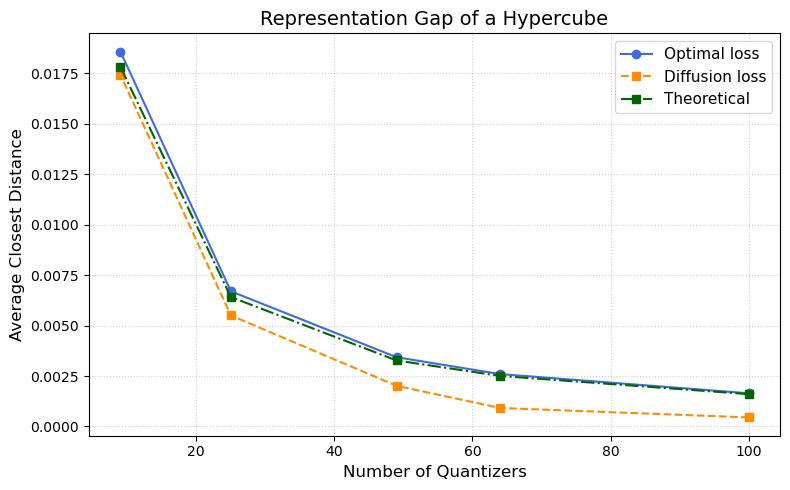

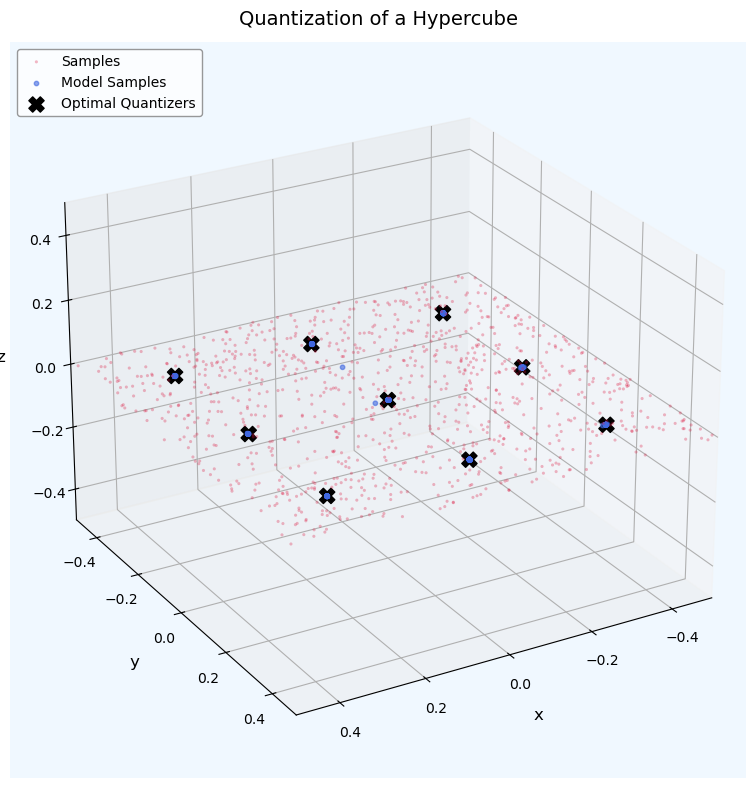

  0%|          | 0/5 [00:00<?, ?it/s]

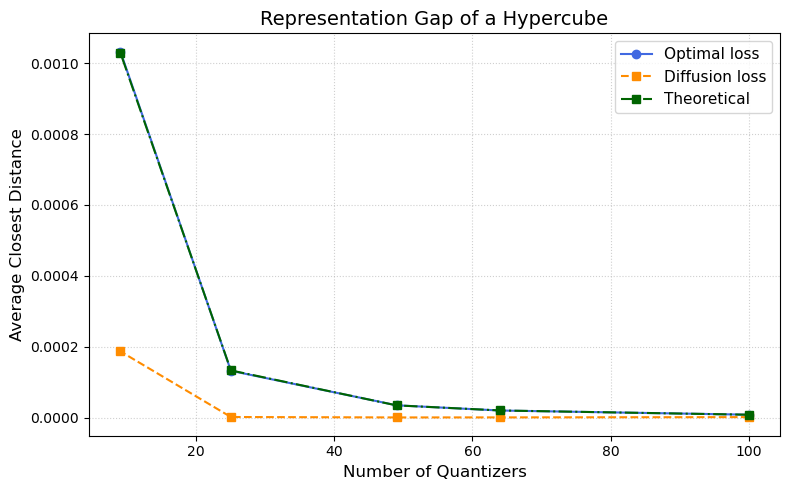

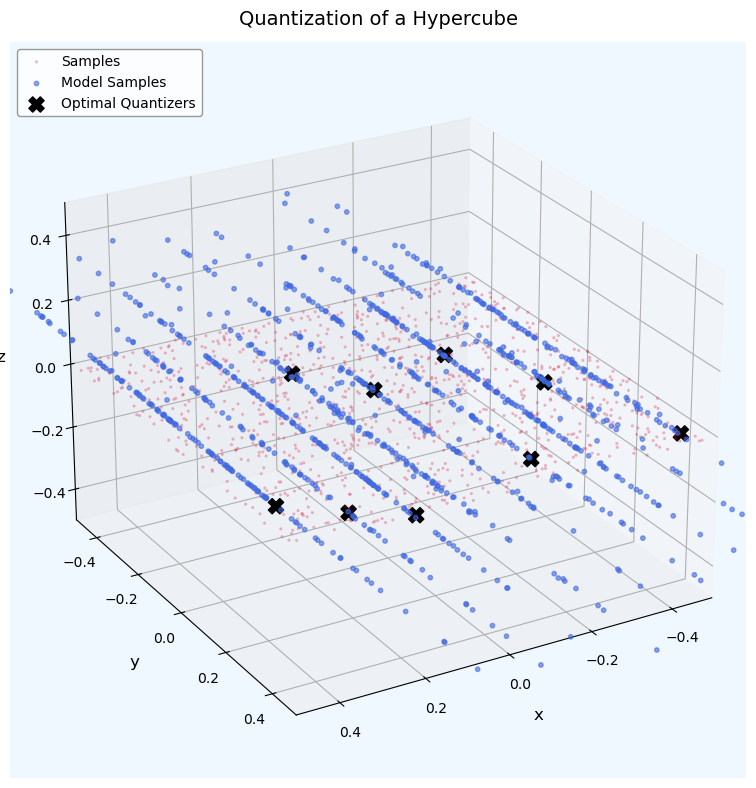

  0%|          | 0/5 [00:00<?, ?it/s]

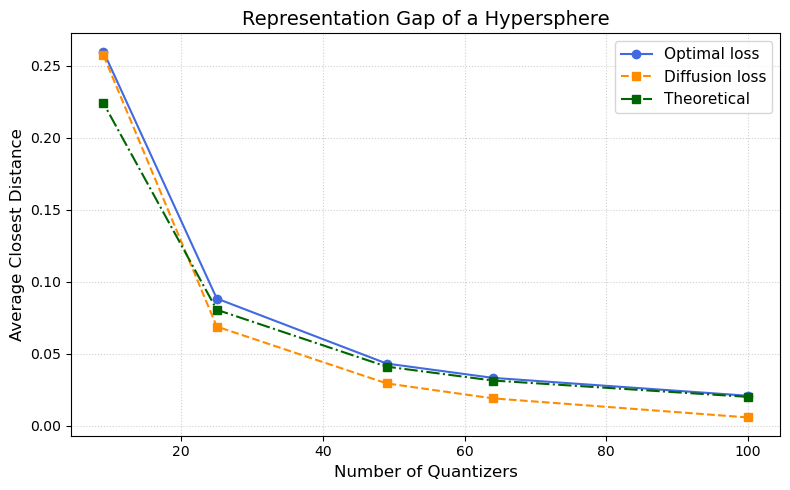

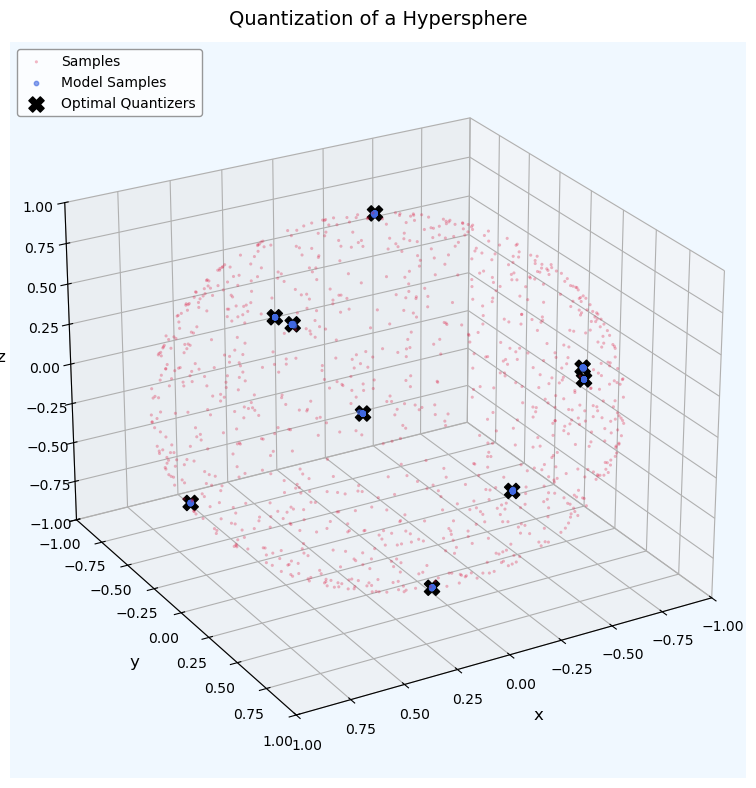

  0%|          | 0/5 [00:00<?, ?it/s]

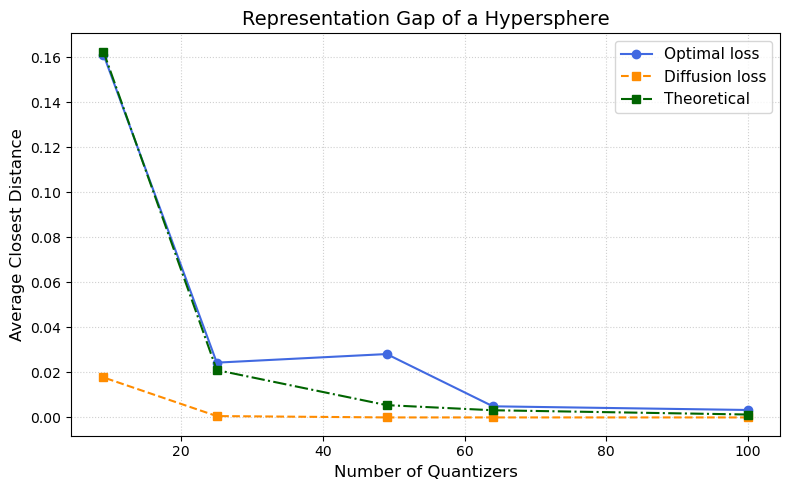

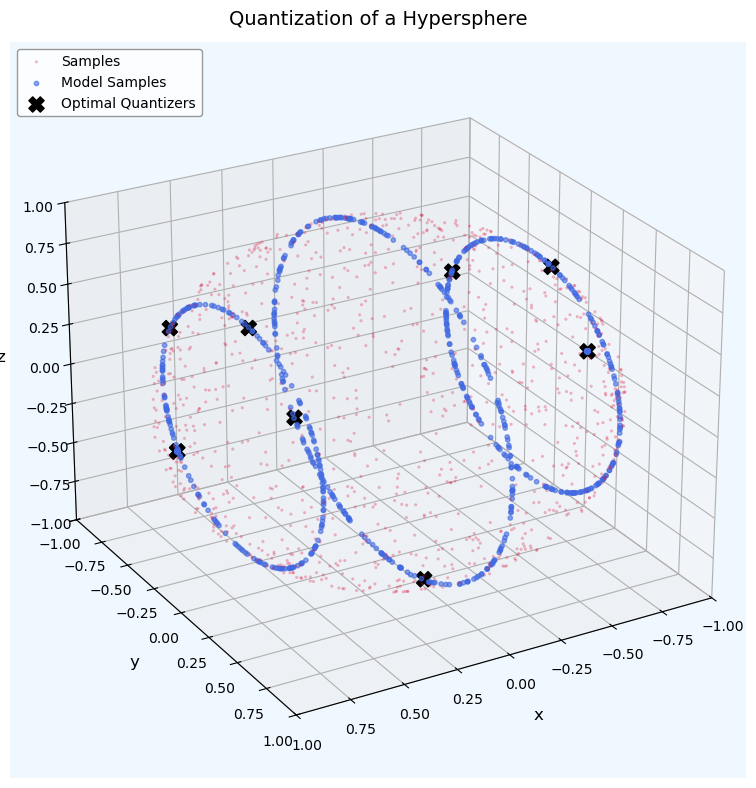

  0%|          | 0/5 [00:00<?, ?it/s]

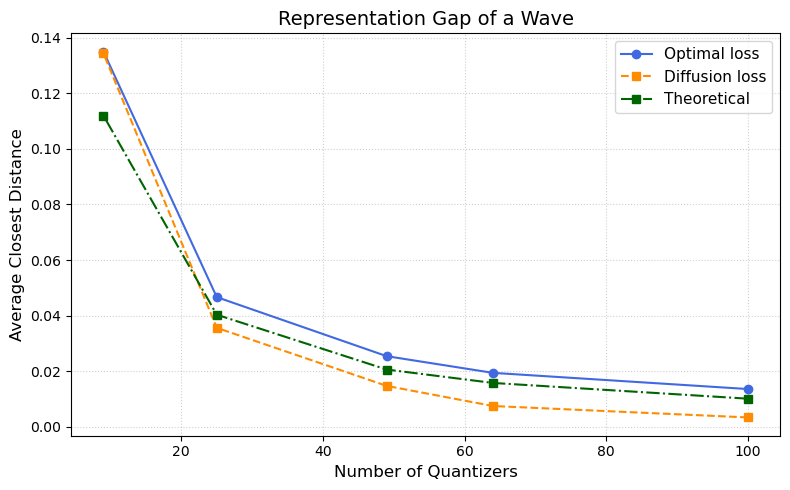

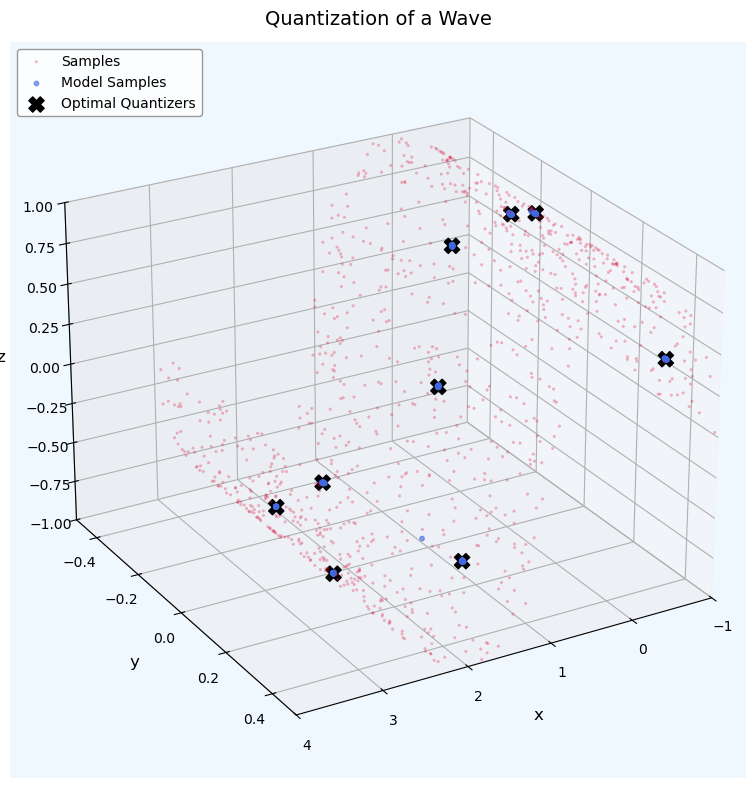

  0%|          | 0/5 [00:00<?, ?it/s]

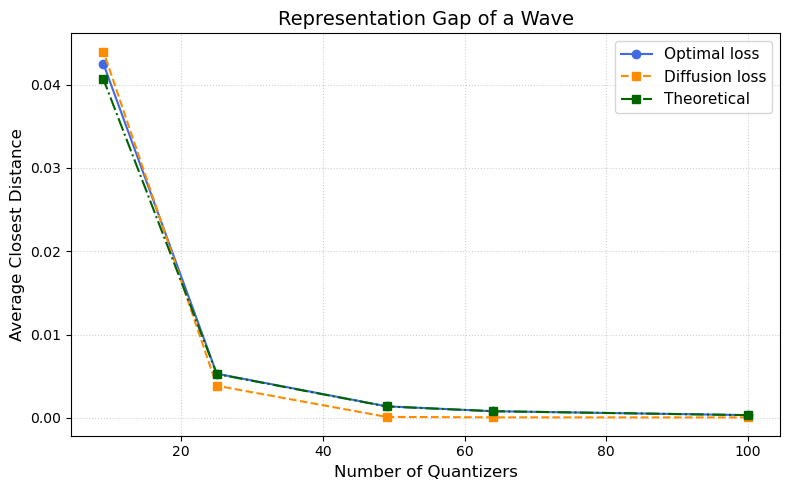

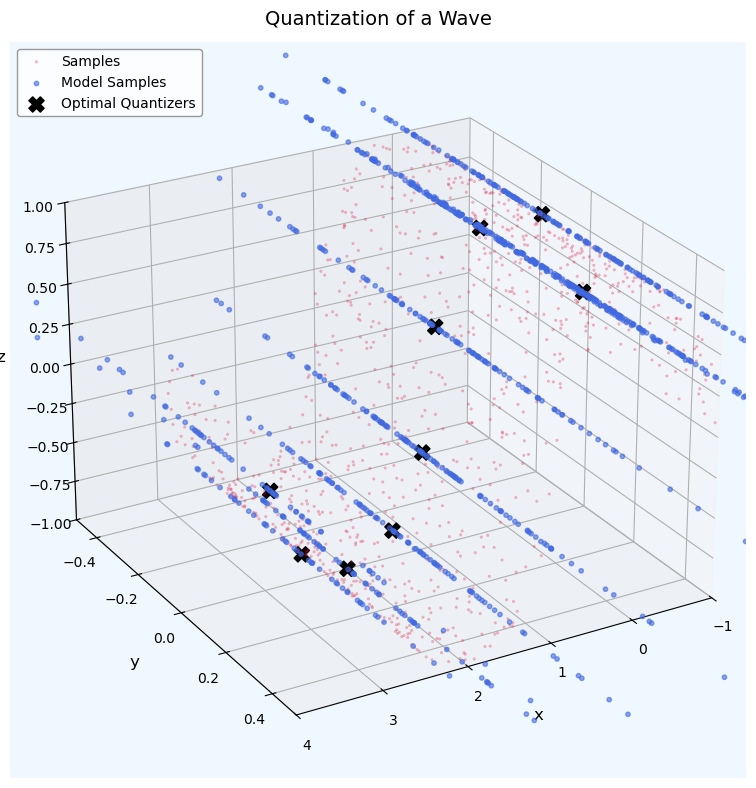

In [2]:
# Compute representation gap for increasing number of quantizers

n_quantizer_list = [100, 64, 49, 25, 9]
dataset_name = "Hypercube"
model_type = "non-equivariant" 
batch_size = 1024
n_sample = 1000
n_model_sample = 1000
T = 100
n_epoch = 50000
device = "cuda"
conf_list = [("Hypercube", "non-equivariant"), ("Hypercube", "equivariant"), ("Hypersphere", "non-equivariant"), ("Hypersphere", "equivariant"), ("Wave", "non-equivariant"), ("Wave", "equivariant")]

for dataset_name, model_type in conf_list:

    if dataset_name == "Hypercube":
        dataset = HypercubeDataset(dim=2, ambient_dim=3)
        optimal_quantizer_sampler = lambda n_quantizer: dataset.get_optimal_quantization(n_quantizer).to(device) if model_type == "non-equivariant" else dataset.get_axis_invariant_quantization(n_quantizer, invariant_axis=1).to(device)
        model = Denoiser(hidden=128, dim=3).to(device) if model_type == "non-equivariant" else AxisEquivariantDenoiser(hidden=256, dim=3, invariant_axis=1).to(device) # 512
        distance_function = mse_distance if model_type == "non-equivariant" else lambda X, Z: mse_distance(torch.stack([X[:,0], X[:,2]], dim=1), torch.stack([Z[:,0],Z[:,2]], dim=1))
        manifold_dimension = 2 if model_type == "non-equivariant" else 1
        plot_lim = [(-0.5, 0.5), (-0.5, 0.5), (-0.5, 0.5)]
    elif dataset_name == "Hypersphere":
        dataset = HypersphereDataset(dim=2, ambient_dim=3, radius=1.0)
        optimal_quantizer_sampler = lambda n_quantizer: dataset.get_optimal_quantization(n_quantizer).to(device) if model_type == "non-equivariant" else dataset.get_axis_invariant_quantization(n_quantizer, circle_axes=(0,1), rotation_axes=(1,2)).to(device)
        model = Denoiser(hidden=128, dim=3).to(device) if model_type == "non-equivariant" else AxisRotationEquivariantDenoiser(hidden=256, invariant_axis=0).to(device) # 512
        distance_function = geodesic_distance if model_type == "non-equivariant" else lambda X, Z: geodesic_distance(torch.stack([X[:,0], X[:,2]], dim=1), torch.stack([Z[:,0],Z[:,2]], dim=1))
        manifold_dimension = 2 if model_type == "non-equivariant" else 1
        plot_lim = [(-1, 1), (-1, 1), (-1, 1)]
    elif dataset_name == "Wave":
        dataset = WavySemicircleSurfaceDataset(radius= 1.0, width= 1.0)
        training_dataset = DummyDataset(dataset.get_batch(n_sample).to(device))
        optimal_quantizer_sampler = lambda n_quantizer: simulated_annealing_quantization(training_dataset, n_quantizers=n_quantizer, distance_function=distance_function, initial_temp=None, n_iters=0, init_mode="lloyd", device=device) if model_type == "non-equivariant" else dataset.get_axis_invariant_quantization(n_quantizer).to(device)
        model = Denoiser(hidden=128, dim=3).to(device) if model_type == "non-equivariant" else AxisEquivariantDenoiser(dim=3, invariant_axis=1).to(device)
        distance_function = mse_distance if model_type == "non-equivariant" else lambda X, Z: mse_distance(torch.stack([X[:,0], X[:,2]], dim=1), torch.stack([Z[:,0],Z[:,2]], dim=1))
        manifold_dimension = 2 if model_type == "non-equivariant" else 1 
        plot_lim = [(-1,4), (-0.5, 0.5), (-1, 1)]
    else:
        raise NotImplementedError

    # compute empirical representation gap
    theoretical_optimal_gap_list = []
    empirical_optimal_gap_list = []
    diffusion_gap_list = []
    for n_quantizer in tqdm(n_quantizer_list):       
        
        # compute optimal representation gap 
        optimal_quantizers = optimal_quantizer_sampler(n_quantizer)
        loss = compute_empirical_representation_gap(dataset, optimal_quantizers, n_sample, distance_function, show_progress=False)
        empirical_optimal_gap_list.append(loss.detach().to("cpu")) 

        # Train Model & generate sample
        training_data = optimal_quantizers.repeat(batch_size // n_quantizer, 1)
        train_diffusion(model, training_data, T=T, epochs=n_epoch, show_progress=False)
        model_samples = sample(model, shape=(n_model_sample, training_data.shape[1]), T=T)   

        # compute diffusion representation gap
        loss = compute_empirical_representation_gap(dataset, model_samples, n_sample, distance_function)
        diffusion_gap_list.append(loss.detach().to("cpu"))

        # compute theoretical representation_gap
        loss = J(manifold_dimension) * dataset.volume() ** (2 / manifold_dimension) / n_quantizer ** (2 / manifold_dimension)
        theoretical_optimal_gap_list.append(loss) 


    # plot empirical & theoretical representation gap
    plt.figure(figsize=(8, 5))
    plt.plot(n_quantizer_list, empirical_optimal_gap_list, label="Optimal loss", marker='o', linestyle='-', color='royalblue')
    plt.plot(n_quantizer_list, diffusion_gap_list, label="Diffusion loss", marker='s', linestyle='--', color='darkorange')
    plt.plot(n_quantizer_list, theoretical_optimal_gap_list, label="Theoretical", marker='s', linestyle='-.', color='darkgreen')
    plt.xlabel("Number of Quantizers", fontsize=12)
    plt.ylabel("Average Closest Distance", fontsize=12)
    plt.title(f"Representation Gap of a {dataset_name}", fontsize=14)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

    # generate samples
    samples = dataset.get_batch(n_sample)

    # plot manifold samples, optimal quantize and diffusion samples
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    fig.suptitle(f"Quantization of a {dataset_name}", fontsize=14)
    ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2], label="Samples", s=5, c="crimson", alpha=0.3, edgecolors='none')
    ax.scatter(model_samples[:, 0].cpu(), model_samples[:, 1].cpu(), model_samples[:, 2].cpu(), label="Model Samples", s=10, c="royalblue", alpha=0.6, marker='o')
    ax.scatter(optimal_quantizers[:, 0].cpu(), optimal_quantizers[:, 1].cpu(), optimal_quantizers[:, 2].cpu(), label="Optimal Quantizers", s=120, c="black", marker="X", alpha=1)
    ax.set_xlim(plot_lim[0][0], plot_lim[0][1])
    ax.set_ylim(plot_lim[1][0], plot_lim[1][1])
    ax.set_zlim(plot_lim[2][0], plot_lim[2][1])
    ax.set_xlabel("x", fontsize=12, labelpad=10)
    ax.set_ylabel("y", fontsize=12, labelpad=10)
    ax.set_zlabel("z", fontsize=12, labelpad=10)
    ax.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='gray')
    ax.view_init(elev=25, azim=60)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_facecolor('#f0f8ff')  # light blue background
    plt.tight_layout()
    plt.show()